<div align="center">

# Pricing a Floating-Strike Asian Call Option on Apple Inc.

### A Binomial Tree and Normal Approximation Approach

---

**6,252: Stochastic Methods in Finance**
University of St. Gallen
Instructor: Dr. Enrico Giorgi

**Alexandru Puspurica** · **Clement Durix**

May 18, 2026

</div>

---

### Abstract

*[ABSTRACT — to be written]*

---

## Table of Contents

0. [Introduction](#intro)
1. [Data and Parameter Estimation](#data)
2. [The Binomial Tree Model](#binomial)
3. [Robustness Check](#robustness)
4. [Sanity Check via Monte Carlo](#mc)
5. [Normal Approximation](#normal)
6. [Conclusion](#conclusion)
A. [Appendix: Derivations](#appendix)

---

<a id="intro"></a>
## 0. Introduction

We consider a six-month floating-strike Asian call on Apple Inc. (AAPL) common stock. Writing $S_t$ for the AAPL price at monitoring date $t = 0, 1, \dots, n$ and

$$
\bar{S}_n \;=\; \frac{1}{n+1}\sum_{t=0}^{n} S_t
$$

for the mean over the $n+1$ monitoring dates (with $t = 0$ counted, so $n = 25$ transitions yield $26$ observations), the contract pays at maturity

$$
A_n \;=\; \max\bigl(S_n - \bar{S}_n,\, 0\bigr) \qquad\qquad (1)
$$

The instrument is monitored weekly over a maturity of $T = 0.5$ years, the risk-free rate is fixed at $r = 1\%$ per annum, and the volatility $\sigma$ is calibrated from AAPL historical daily log-returns spanning 2020–2026.

Because the payoff in (1) depends not only on the terminal price $S_n$ but also on the mean $\bar{S}_n$ — which is itself determined by the specific path leading to $S_n$ — two paths reaching the same node with the same number of up and down moves can carry different averages and therefore different payoffs. The valuation is, in this sense, *path-dependent*.

We obtain the arbitrage-free price of (1) by two independent routes. First, we construct a Cox–Ross–Rubinstein (CRR) binomial tree, and to accommodate path-dependence we augment the state space so that each path carries its running cumulative sum

$$
C_t \;=\; \sum_{j=0}^{t} S_j,
$$

from which the running average is recoverable at every node. Under the risk-neutral probability measure $Q$, the value at each node is the expectation of its two successor values weighted by the risk-neutral probability $q$, multiplied by the one-step discount factor $e^{-r\Delta t}$ where $\Delta t = T/n$. Iterating this recursion back to $t = 0$ compounds the per-step discount into the full discount factor $e^{-rT}$, yielding the arbitrage-free price

$$
C_0 \;=\; e^{-rT}\,\mathbb{E}^{Q}\!\left[A_n\right].
$$

Second, *[PLACEHOLDER — normal-approximation method, to be written by [group member's name]: brief description of approximating $D_n = S_n - \bar{S}_n$ as Gaussian under $Q$, deriving its first two moments, and applying the closed-form expectation of a censored normal random variable to obtain a price in closed form.]*

As an independent check on the binomial price, a Monte Carlo simulation of risk-neutral paths is also performed.

In [4]:
# Import all the packages we need
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm
import seaborn as sns
import math
import time




<a id="data"></a>
## 1. Data and Parameter Estimation

The first step is to use historical Apple stock prices from 2020 to 2026 to estimate $\sigma$; to do this we use an API. The Yahoo Finance API specified in the project is no longer free, so instead we use a free alternative named Stooq. No sign-up was required; however, an API key had to be obtained from the CSV-download page of the Stooq website.

To pull the data, a function is defined that reads the CSV directly from the AAPL URL; the resulting series is then sorted by date and the date is set as the index for easy access. We subsequently call this function to retain only the dates relevant to the project.

To verify completeness, we check the number of observations against the project’s assumption of approximately 250 trading days per year, and the count obtained from the pulled data is consistent with this benchmark.

In [5]:

APIKEY = "COa2gJQuK0X1c4DihNGzTxIFH8pf3Md7"

def get_aapl_prices():
    url = f"https://stooq.com/q/d/l/?s=aapl.us&i=d&apikey={APIKEY}"
    data = pd.read_csv(url)
    data["Date"] = pd.to_datetime(data["Date"])
    data = data.sort_values("Date")
    return data.set_index("Date")["Close"]

#set the stock prices we got equal to a variable
all_prices = get_aapl_prices()

#select only the prices for the timeframe which was asked for the project
prices = all_prices.loc["2020-01-01":"2026-04-30"]

#lets see the amount of loaded prices from the start date to the end date
print("Loaded", len(prices), "daily prices from", prices.index[0].date(), "to", prices.index[-1].date())
print("Exexpected data points around: ", 250*(2026-2020))


Loaded 1590 daily prices from 2020-01-02 to 2026-04-30
Exexpected data points around:  1500


Now that we have our data lets graph the retuns and log returns to ensure our data looks clean before estimating sigma.


Log returns are commonly used in finance because for small movements they are approximately equal to the simple return,

$$
r_t \;=\; \log(1 + R_t) \;\approx\; R_t \qquad \text{for small } R_t,
$$

and they are additive over time which greatly reduces computational needs when running financial calculations.

$$
\log\!\left(\frac{S_n}{S_0}\right) \;=\; \sum_{t=1}^{n} r_t.
$$

From Chapter 1 (lecture slide 58, *Stochastic Methods in Finance*) the log-return is defined as

$$
r_t \;:=\; \log\!\left(\frac{S_t}{S_{t-1}}\right) \;=\; \log S_t - \log S_{t-1}, \qquad\qquad (2)
$$

Also log returns are what is used in both the binomial tree and the geometric Brownian motion models which we have to use later on, where the variance condition takes the form

$$
\operatorname{Var}\!\left[\log\!\left(\frac{S_n}{S_0}\right)\right] \;=\; \sigma^2 T.
$$


Missing prices: 0
Missing log returns: 0


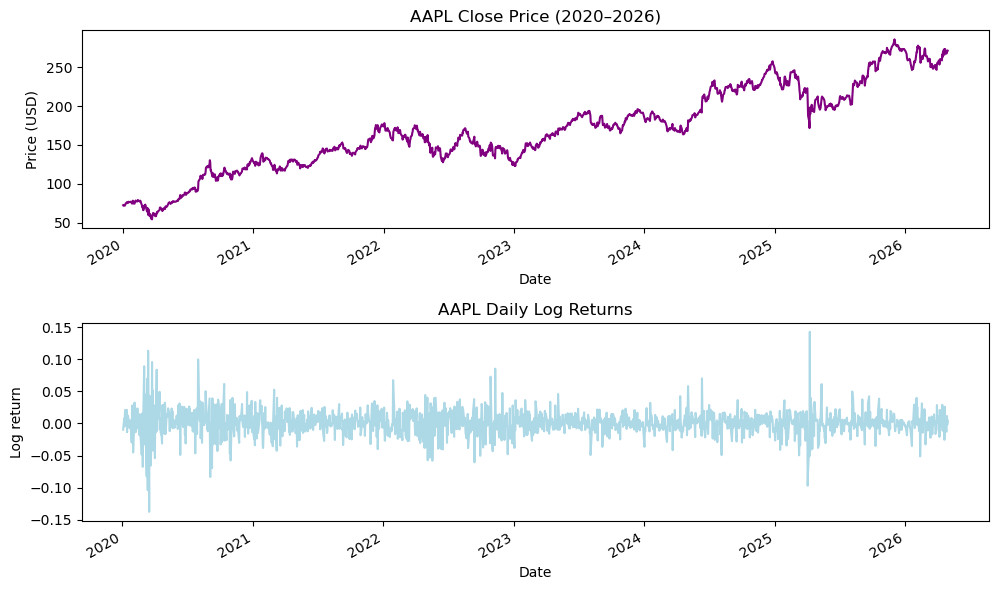

In [6]:
log_returns = np.log(prices / prices.shift(1)).dropna() # The first row is NA becuse there is no S0_t-1 so we have a dropna() to remove this one problematic row

# Even before printing i want to make sure that there are no missing values because I've had difficulty in the past with this
print("Missing prices:", prices.isna().sum())
print("Missing log returns:", log_returns.isna().sum())

#Lets make a plot for apple stock closing prices and the log returns
fig, axes = plt.subplots(2, 1, figsize=(10, 6))
prices.plot(ax=axes[0], title="AAPL Close Price (2020–2026)", color="purple")
axes[0].set_ylabel("Price (USD)")
log_returns.plot(ax=axes[1], title="AAPL Daily Log Returns", color="lightblue")
axes[1].set_ylabel("Log return")
plt.tight_layout()
plt.show()


Now that we have pulled the data and computed the log-returns we need to create the parameters, most of which were given in the assignment, that are used by the floating-strike Asian price model. For the initial price $S_0$ we use the last day of trading we have from our data.

Sigma is the only parameter which we are estimating, which is done under the assumption that AAPL follows a geometric Brownian motion, $dS_t = \mu S_t\,dt + \sigma S_t\,dW_t$. Applying Itô's lemma gives us the constant variance log price process $d(\log S_t) = (\mu - \tfrac{1}{2}\sigma^2)\,dt + \sigma\,dW_t$, so the variance of one daily log-return (Equation 2) equals $\sigma_{\text{daily}}^2$. Sigma is then estimated as $\sigma_{\text{daily}}$, which is the sample standard deviation of the log-return series, its then turned into an annual value under the 250 trading day convention which was given in the assignment.

$$
\sigma \;=\; \sigma_{\text{daily}} \cdot \sqrt{250},  \qquad\qquad (3)
$$

this formula is justified by the linear scaling of variance with time under the i.i.d. assumption.

The up and down factors of the binomial tree are then chosen so that one tree step matches the variance of one $\Delta t$-step of the underlying geometric Brownian motion (Cox, Ross, & Rubinstein, 1979; Chapter 2). The standard CRR choice is

$$
u \;=\; e^{\sigma\sqrt{\Delta t}}, \qquad d \;=\; e^{-\sigma\sqrt{\Delta t}} \;=\; \frac{1}{u}, \quad (\text{see Appendix A.1}) \qquad\qquad (4)
$$

with the physical up-probability set to $p = \tfrac{1}{2}$ as stated in the project instructions.


In [7]:
# Parameters given by the assignment

# Maturity
T  = 0.5
# Number of binomial periods
n  = 25
#change in time for each period
dt = T / n
# Risk-free rate per annum
r  = 0.01
# the probability of an up move
p = 0.5
# Initial stock price (last day of trading)
S0 = all_prices.loc["2026-04-28"]


# Now we have to find sigma

#we compute the daily volitility 
sigma_daily = log_returns.std()

#rescale to a yearly value (convention of CRR)
sigma = sigma_daily * np.sqrt(250) 


# use simga to compute u and d as given by our derived formulas

# e ^ sigma * sqrt(dt)
u = np.exp(sigma * np.sqrt(dt))
# e ^ -sigma * sqrt(dt) or 1/u
d = np.exp(-sigma * np.sqrt(dt))


# Before we move on lets so a sanity check to make sure all the variables look like something we would expect

print(f"T            = {T}")
print(f"n            = {n}")
print(f"r            = {r}")
print(f"S_0          = {S0:.2f} USD")
print(f"sigma_daily  = {sigma_daily:.6f}")
print(f"sigma_annual = {sigma:.6f}")
print(f"u            = {u:.6f}")
print(f"d            = {d:.6f}")
print(f"p            = {p}")


T            = 0.5
n            = 25
r            = 0.01
S_0          = 270.71 USD
sigma_daily  = 0.019784
sigma_annual = 0.312816
u            = 1.045232
d            = 0.956725
p            = 0.5


<a id="binomial"></a>
## 2. The Binomial Tree Model

The physical up-probability $p = \tfrac{1}{2}$ is the probability of the number of up moves and down moves in nature but p can not be used to price the option directly because its an unobservable value which is based on your beleive about the stock; two participants disagreeing on $p$ would still have to agree on the price for the derivative otherwise one could arbitrage the other. The arbitrage-free price must therefore depend only on observable quantities — $S_0$, $u$, $d$ and $r$ and not subjective belief. Sigma is included through the derivations of u and d which were done above

For this reason we caculutate the **risk-neutral probability** $q$, which is the synthetic up probability where the discounted stock price is martingale meaning its  expected future value given everything known today equals its current value. Solving $S_t = e^{-r\Delta t}\,\mathbb{E}^Q[S_{t+\Delta t}\mid\mathcal{F}_t]$ for $q$ gives

$$
q \;=\; \frac{e^{r\Delta t} - d}{u - d}, \quad (\text{see Appendix A.2}) \qquad\qquad (5)
$$

which has the domain $(0,1)$ only if the no-arbitrage condition $d < e^{r\Delta t} < u$ holds The Fundamental Theorem of Asset Pricing (Chapter 2) then guarantees that the arbitrage-free price of any derivative is its discounted expected payoff under $Q$, a principle we apply by backward induction in the cells that follow.



In [ ]:
q = (np.exp(r * dt) - d) / (u - d)

# if q is outside (0,1) the model would admit to arbitrage and an assumption of modern markets is no arbitrage so lets make a sanity check on q to make sure everything is fine. If something is wrong the program will crash. 
assert 0 < q < 1, f"q = {q:.4f} outside (0,1) — model admits arbitrage!"

print(f"q = {q:.6f}")


q = 0.491202


Because the payoff from equation (1) depends on the entire path through the average $\bar{S}_n$, the option value at an interior node cannot be expressed as a function of the up-count $j$ alone. This is because two paths reaching the same $(t, j)$ probably have different running averages because the up and down moves scale by a percentage of the price and the base price being different depening on the previous moves.Ttherefore they have different future payoffs. We resolve this by augmenting the states with the running cumulative sum $C_t = \sum_{k=0}^{t} S_k$, where the running average $\bar{S}_t = C_t/(t+1)$ is accessable at every node (Chapter 2, *Stochastic Methods in Finance* lecture notes).

Keeping all of this in mind, we need to structure the tree as `list[dict[set]]`: `states[t]` 

Where the stucture look ssomething like this: ....

Once the parameters $T$, $n$, $\sigma$, $r$ and $S_0$ are fixed, the function first computes the per-step constants

$$
\Delta t \;=\; \tfrac{T}{n}, \qquad u \;=\; e^{\sigma\sqrt{\Delta t}}, \qquad d \;=\; e^{-\sigma\sqrt{\Delta t}}, \qquad q \;=\; \tfrac{e^{r\Delta t} - d}{u - d}, \qquad \mathrm{disc} \;=\; e^{-r\Delta t},
$$

drawn from Equations (4) and (5). The tree is then initialised at $t = 0$ by placing the single triple $(0,\, 0,\, C_0)$ with $C_0 = S_0$ — only one price has been recorded so far, so the cumulative sum equals $S_0$.

The **forward pass** iterates over the $n$ transitions $t = 0, 1, \ldots, n-1$. At each existing triple $(t, j, C)$ the path-independent node price

$$
S_{t,j} \;=\; S_0\,u^{\,j}\,d^{\,t-j}
$$

is computed once, and the triple spawns two children — one with up-count $j+1$ and cumulative sum $C + S_{t,j}\,u$, one with up-count $j$ (unchanged) and cumulative sum $C + S_{t,j}\,d$:

$$
(t, j, C) \;\longrightarrow\; \begin{cases} (t+1,\, j+1,\, C + S_{t,j}\,u) & \text{(up)}, \\[2pt] (t+1,\, j,\;\;\, C + S_{t,j}\,d) & \text{(down)}. \end{cases} \qquad\qquad (6)
$$

A new set is created in `states[t+1]` only when the child up-count does not yet have one, so reads come only from level $t$ and writes only to level $t+1$ — no past node is ever disturbed.

At maturity ($t = n$), each terminal triple $(n, j, C)$ produces the floating-strike Asian call payoff

$$
A_n(j, C) \;=\; \max\!\bigl(S_{n,j} - C/(n+1),\, 0\bigr),
$$

which is exactly Equation (1) with $\bar{S}_n$ rewritten as $C/(n+1)$. The negative branch is floored at zero because a call option is never exercised at a loss.

The **backward pass** then runs from $t = n-1$ down to $t = 0$, applying the risk-neutral pricing relation at every node:

$$
V_t(j, C) \;=\; \mathrm{disc}\,\bigl[\,q\,V_{t+1}\!\bigl(j+1,\, C + S_{t,j}\,u\bigr) \;+\; (1-q)\,V_{t+1}\!\bigl(j,\, C + S_{t,j}\,d\bigr)\,\bigr]. \qquad\qquad (7)
$$

Each parent value is the discounted risk-neutral expectation of its two children, looked up via the same $C$-update rule as in the forward pass. Iterating (7) collapses the entire tree onto the unique root $(t=0,\,j=0,\,C=S_0)$, and the function returns $V_0(0, S_0)$ — the arbitrage-free price of the option today. *[Derivations of (6) and (7) deferred to Appendix A.3.]*

In [7]:
# now is time for the fun part we have to define a function which applies the paramenters of 
def price_floating_asian(S0, sigma, r, T, n):
    # the first step is to define our varibales from the value of the given parameters
    dt   = T / n
    u    = np.exp(sigma * np.sqrt(dt))
    d    = np.exp(-sigma * np.sqrt(dt))
    q    = (np.exp(r * dt) - d) / (u - d)
    disc = np.exp(-r * dt)

    #the next step is to create the structure of our tree and every possible outcome which is done using states where each possible outcome gives birth to two child outcomes which are a summing cumulative product of S0 and u and d which we will then map values to in a later function
    #The tree need the shape list[dict[set]]:
        #state[t] is the dictionary at each time point
        #states[t][j] is the set of all reachable cumulative sums C at not (t,j)
    # we need to make a nexted path because the option is path dependent and we need to teen them seperate without having the number of of dictionaries explode which would be bad for our computing budget
    states = []
    
    # the tree has n transitions but n+1 time points: t = 0, dt, 2dt, ..., n·dt = T and we need a dict at every time point, so range is n+1,  don't forget t=0!
    for t in range(n + 1): 
        #for each of the steps we create a dictionary which is keyed by the number of up moves so far
        #values get filled by foward pass
        states.append({})
    #We also need to set the cumulative sum to S0 since only one price is recorded at t=0
    states[0][0] = {S0}

# now we need to define what happens at each time step above we made the time points but now we need what happens in the transition
# for every time t we need to spawn two children one with up move values and one with down move values
#Things to consider
    # we have to make sure to only read from t and only write into t+1 so we dont mess up any past nodes
    # use range(n) because here we are doing the transitions not the time points 
    for t in range(n):
        #now we have to loop over every up move so we iterates h through every kety strored in states[t]
        for j in list(states[t].keys()):
            #now on each iteration we set one specific up count value 0, then 1, then 2, ect. through states[t][j] which is a set containing every distinct cumulative sum through all paths that point to this state node
            c_set = states[t][j] #specified as value to avoid repeated hashing and for readability

            # we now have to compute the current stock price at each j in each t to do that we just nultiply S0 by the number of up moves and the up move value and the number of down moves and the down move value this value is path independent
            S_now = S0 * (u ** j) * (d ** (t - j))

            #we are now inside the t and j loop so now we are at a specific node where c_set is the set of all cummulative sums recorded at that node
            # in c_set are elements containing the path history that arrived at (t,j) on each pass c must be calculated as one specific float 
            for C in c_set:
                # now we need if j+1 (childs up count) is not already a key in states[t+1] (the dict for the next time level) then we need to cteate a new empty set at that key to store the C values 
                if (j + 1) not in states[t + 1]:
                    states[t + 1][j + 1] = set()
                #then we add the value of the the up move to the C value for the next time frame
                states[t + 1][j + 1].add(C + S_now * u)
                # We do the same thing for the down count but we have to remember not to change the up count so NO j+1 on the index and to use d instead of u
                if j not in states[t + 1]:
                    states[t + 1][j] = set()
                states[t + 1][j].add(C + S_now * d)

    # Now that we calulcuated the states we need to calculate the values
    values = []

    # we again make a dictionary at each time point +1
    for t in range(n + 1):
        values.append({})

    # now we acess each last time level n which have key values of j which includes all j values of (0->n) (all up moves, all down moves, and everything inbetweem)
    for j in states[n]:
        #then we compute the terminal value at the right most part of the tree from top to botoom and fill values for all S terminals at that time step n this is not S-now but S_t becuase is the terminal price at maturity
        S_T = S0 * (u ** j) * (d ** (n - j))
        #next we make an empty dictionary at this slot in values to map the cummulative sums to option values where each c is a key  and each payofff will be the value
        values[n][j] = {}

        #now we loop over every cumulative sum C which is one path history that reached (n,j)
        for C in states[n][j]:
            #now we can calculate the maturity at payooff for each node using the floating-strike asian call payoff formula
            payoff = S_T - C / (n + 1) #IN FINAL SUBMISSION HAVE DERIVATION OF FORMULA HERE

            #make sure negative payoffs are zero because call options can never have a negative payoff because you simply would not exercise option if you lose money jsut take max of payoff or 0
            payoff = max(payoff,0.0)
            #for each time frame acess each j key and then set the value equal to the payoff 
            values[n][j][C] = payoff

# So far we've built the full grid of reachable augmented states (t, j, C) in the
# forward pass and pinned down the option's payoff at every terminal node (t=n).
# All that's left is backward induction: take those terminal payoffs and roll them
# back through the tree, at each node computing the discounted risk-neutral
# expected value of its two children, until we collapse everything down to a single
# number at (t=0, j=0, C=S0) — the arbitrage-free option price today.

    # we start at n-1 for backword induction because n was already filled bye the termila payoffs and go all the way to 0, you must include -1 as the stop value because python does not include the stop value in the formula, the step must be -1 because we are counting backwards
    for t in range(n - 1, -1, -1):
        # fro every up count j at this time level we process every node 
        for j in states[t]:
            #compute the current stcok price at node which is path independnet so its outside the C loop
            S_now = S0 * (u ** j) * (d ** (t - j))
            #we now make an empty dictionary at this node to holde the C->V mappings
            values[t][j] = {}
            #now we loop through each c which is one sepciifc path history to get the value of the up child and the down child  because to compute the option value we need to know these two values which are filled in from the pervious loop
            for C in states[t][j]:
                #we have to get the values by accessing the dict at the next time level up, get the childs up count which is one more than the parents and inside that dict look up the entry for the childs cumulative sum
                #the childs cumulative sum is the cumalitive sum of the parent plus the price now times u or d respectivally
                V_up = values[t + 1][j + 1][C + S_now * u] 
                V_dn = values[t + 1][j    ][C + S_now * d]
                #now we have to use the formula that actually computes the option value at this node — the discounted risk-neutral expectation of the two children
                #V_t = disc * (q * V_up + (1-q) * V_dn) — derived from the replication argument
                #IN FINAL SUBMISSION HAVE DERIVATION OF FORMULA HERE
                # we then use the value the formula gave out and index it to the current time frame at the correct j count  in the slot for the cummulative sum
                values[t][j][C] = disc * (q * V_up + (1 - q) * V_dn)

    # we then have to return the abritrage free price of the option today which is just the first node of the backward inductuon and then we access the key for the first original parent value S0
    return values[0][0][S0] 

In [8]:
%%time
# now that we defined the function lets actually run it and also see how long it takes.

price_binomial = price_floating_asian(S0, sigma, r, T, n)

print(f"Binomial price at t=0 : {price_binomial:.4f} USD")


Binomial price at t=0 : 14.0418 USD
CPU times: user 2.13 s, sys: 102 ms, total: 2.24 s
Wall time: 2.26 s


<a id="robustness"></a>
## 3. Robustness Check

*[to be written]*

In [10]:
#"Following common practice in option pricing sensitivity analysis (see e.g. Saltelli et al., 2008, for an overview of methods), we conduct a two-way scenario-based robustness check by varying the risk-free rate r and volatility σ over a discrete grid around their baseline values. Because we vary both parameters jointly on a 5×5 grid rather than one-at-a-time, we also capture interaction effects between r and σ."

# we first define some ranges of r around the r wich was used in the assignment of 1 as the x axis
r_grid     = [0.0, 0.005, 0.01, 0.015, 0.02]

#next we use some volatility values around around our basleine siqma as the y axis
sigma_grid = [sigma * 0.8, sigma * 0.9, sigma, sigma * 1.1, sigma * 1.2]

#we have to constuct a dataframe in which sigma is the index and the interest rate is the features 
results = pd.DataFrame(
    index=[f"{s:.4f}" for s in sigma_grid],
    columns=[f"{rr:.2%}" for rr in r_grid],
    dtype=float,
)
#noew e label the index and the coulms to help us visualize our data
results.index.name   = "sigma"
results.columns.name = "r"

#now we have to loop out option pricing over each interest rate at each sigma and we can use a nested for loop for that
for s_val in sigma_grid:
    for r_val in r_grid:
        price = price_floating_asian(S0, s_val, r_val, T, n)
        results.loc[f"{s_val:.4f}", f"{r_val:.2%}"] = price

print("Floating-strike Asian call price (USD):")
print(results.round(4))

Floating-strike Asian call price (USD):
r         0.00%    0.50%    1.00%    1.50%    2.00%
sigma                                              
0.2503  10.9841  11.1449  11.3070  11.4705  11.6353
0.2815  12.3545  12.5141  12.6748  12.8367  12.9997
0.3128  13.7240  13.8824  14.0418  14.2022  14.3636
0.3441  15.0925  15.2497  15.4078  15.5668  15.7267
0.3754  16.4599  16.6159  16.7728  16.9304  17.0888


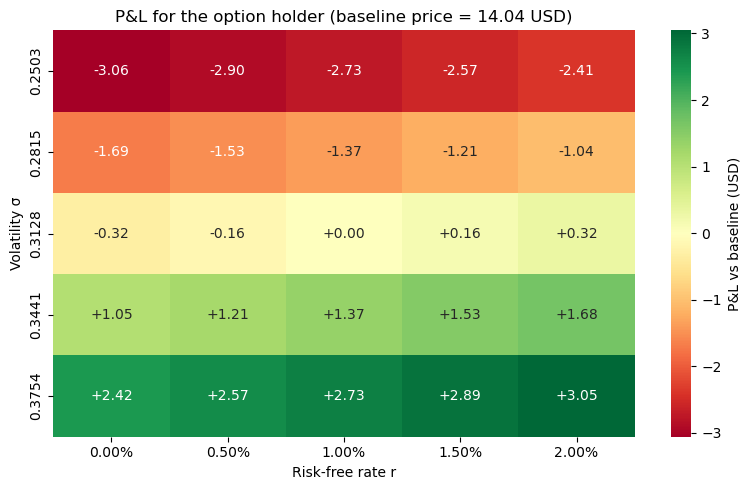

In [12]:
# lets print the results in a prettier table


baseline = results.loc[f"{sigma:.4f}", f"{r:.2%}"]
# P&L from the buyer's perspective: realized fair price minus what we paid at baseline
pnl = results - baseline

fig, ax = plt.subplots(figsize=(8, 5))
ax.grid(False)  # turn off the global rcParams grid so it doesnt draw lines through the heatmap cells
# RdYlGn: red for negative (loss), yellow near zero, green for profit — like a stock-market P&L heatmap
sns.heatmap(pnl, annot=True, fmt="+.2f", cmap="RdYlGn", center=0,
            cbar_kws={"label": "P&L vs baseline (USD)"}, ax=ax)
ax.set_title(f"P&L for the option holder (baseline price = {baseline:.2f} USD)")
ax.set_xlabel("Risk-free rate r")
ax.set_ylabel("Volatility σ")
plt.tight_layout()
plt.show()

<a id="mc"></a>
## 4. Sanity Check via Monte Carlo

*[to be written]*

In [15]:
# Not a required part of the assignment but as an extra sanity check for the model lets run a monte carlo simulation to see if our call option pricer actually worked

#We need a function that takes the same inputs as the option pricer and also a number of paths for random simulations and a seed for replicability
def monte_carlo_floating_asian(S0, sigma, r, T, n, n_sims=200_000, seed=42):
    
    # Set the random seed so we get the same result every run
    np.random.seed(seed)
    
    # Length of one time step
    dt = T / n
    
    # Pre-draw all the random numbers we need at once: one matrix of shape (n_sims, n)
    Z = np.random.standard_normal((n_sims, n))
    
    # Container for the payoff of each simulated path
    payoffs = np.zeros(n_sims)
    
    # Loop over each simulated path
    for i in range(n_sims):
        
        # Start the path at S0
        price_path = [S0]
        
        # Simulate n forward steps
        for t in range(n):
            # GBM log-return for this step (risk-neutral dynamics)
            log_return = (r - 0.5 * sigma**2) * dt + sigma * math.sqrt(dt) * Z[i, t]
            
            # New price = old price * exp(log_return)
            new_price = price_path[-1] * math.exp(log_return)
            price_path.append(new_price)
        
        # Average price along this path
        avg_price = sum(price_path) / len(price_path)
        
        # Terminal price is the last entry of the path
        terminal_price = price_path[-1]
        
        # Floating-strike Asian call payoff: max(S_n - average, 0)
        payoffs[i] = max(terminal_price - avg_price, 0)
    
    # Discounted expected payoff = Monte Carlo price estimate
    price = math.exp(-r * T) * payoffs.mean()
    
    # Standard error of the estimate
    se = math.exp(-r * T) * payoffs.std(ddof=1) / math.sqrt(n_sims)
    
    return price, se


# Run the Monte Carlo and compare with the binomial price 

mc_price, mc_se = monte_carlo_floating_asian(S0, sigma, r, T, n)

# 95% confidence interval
ci_lo = mc_price - 1.96 * mc_se
ci_hi = mc_price + 1.96 * mc_se

# Print results
print(f"Monte Carlo (200k paths) : {mc_price:.4f} USD")
print(f"  95% CI                 : [{ci_lo:.4f}, {ci_hi:.4f}]")
print(f"Binomial price           : {price_binomial:.4f} USD")
print(f"Absolute difference      : {abs(mc_price - price_binomial):.4f} USD")

Monte Carlo (200k paths) : 13.9071 USD
  95% CI                 : [13.8050, 14.0092]
Binomial price           : 14.0418 USD
Absolute difference      : 0.1346 USD


<a id="normal"></a>
## 5. Normal Approximation

*[to be written]*

In [10]:
m1 = np.exp(r * dt)
m2 = q * u**2 + (1 - q) * d**2

ES = np.zeros(n + 1)
for t in range(n + 1):
    ES[t] = S0 * m1**t

cov_mat = np.zeros((n + 1, n + 1))
for s in range(n + 1):
    for t in range(n + 1):
        E_SsSt        = S0**2 * m2**min(s, t) * m1**abs(s - t)
        cov_mat[s, t] = E_SsSt - ES[s] * ES[t]

sum_ES = 0.0
for t in range(n + 1):
    sum_ES += ES[t]
E_Dn = ES[n] - sum_ES / (n + 1)

Var_Sn = cov_mat[n, n]

cov_Sn_sum = 0.0
for t in range(n + 1):
    cov_Sn_sum += cov_mat[n, t]

cov_total = 0.0
for s in range(n + 1):
    for t in range(n + 1):
        cov_total += cov_mat[s, t]

Var_Dn = Var_Sn - 2/(n+1) * cov_Sn_sum + cov_total / (n + 1)**2
sd_Dn  = np.sqrt(Var_Dn)

ratio        = E_Dn / sd_Dn
price_normal = np.exp(-r * T) * (E_Dn * norm.cdf(ratio) + sd_Dn * norm.pdf(ratio))

print(f"m_1                        = {m1:.6f}")
print(f"m_2                        = {m2:.6f}")
print(f"mu_D  (E[D_n])             = {E_Dn:.4f} USD")
print(f"sd_D  (sqrt(Var[D_n]))     = {sd_Dn:.4f} USD")
print()
print(f"Normal-approximation price = {price_normal:.4f} USD")
print(f"Binomial price             = {price_binomial:.4f} USD")
print(f"Absolute difference        = {price_normal - price_binomial:+.4f} USD")
print(f"Relative difference        = {(price_normal - price_binomial)/price_binomial:+.2%}")

m_1                        = 1.000200
m_2                        = 1.002361
mu_D  (E[D_n])             = 0.6712 USD
sd_D  (sqrt(Var[D_n]))     = 34.6769 USD

Normal-approximation price = 14.1016 USD
Binomial price             = 13.8933 USD
Absolute difference        = +0.2083 USD
Relative difference        = +1.50%


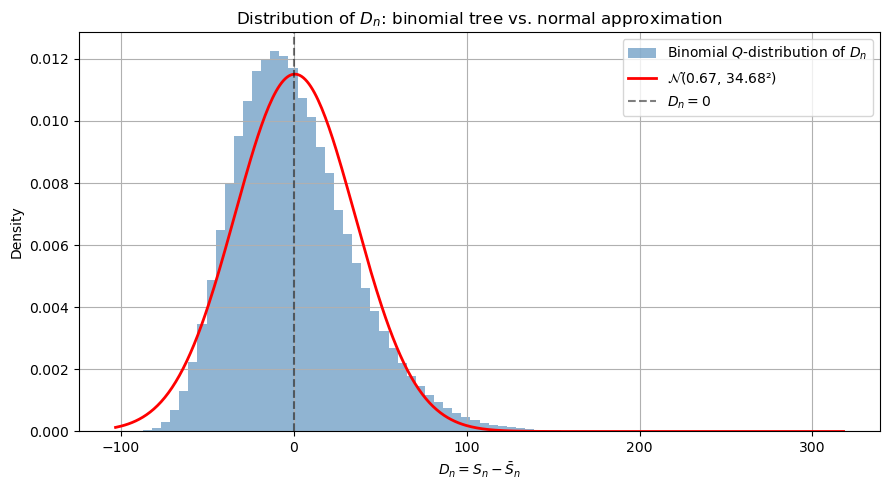

In [ ]:
# Here starts the normal Approximation

prob_states = []
for t in range(n + 1):
    prob_states.append({})
prob_states[0][0] = {S0: 1.0}

for t in range(n):
    for j in list(prob_states[t].keys()):
        c_dict = prob_states[t][j]
        S_now  = S0 * (u**j) * (d**(t - j))
        for C in c_dict:
            prob = c_dict[C]
            if (j + 1) not in prob_states[t + 1]:
                prob_states[t + 1][j + 1] = {}
            new_C_up = C + S_now * u
            if new_C_up in prob_states[t + 1][j + 1]:
                prob_states[t + 1][j + 1][new_C_up] += prob * q
            else:
                prob_states[t + 1][j + 1][new_C_up] = prob * q
            if j not in prob_states[t + 1]:
                prob_states[t + 1][j] = {}
            new_C_dn = C + S_now * d
            if new_C_dn in prob_states[t + 1][j]:
                prob_states[t + 1][j][new_C_dn] += prob * (1 - q)
            else:
                prob_states[t + 1][j][new_C_dn] = prob * (1 - q)

Dn_values = []
Dn_probs  = []
for j in prob_states[n]:
    S_T = S0 * (u**j) * (d**(n - j))
    for C in prob_states[n][j]:
        Dn_values.append(S_T - C / (n + 1))
        Dn_probs.append(prob_states[n][j][C])
Dn_values = np.array(Dn_values)
Dn_probs  = np.array(Dn_probs)

assert abs(Dn_probs.sum() - 1.0) < 1e-9, "Q-probabilities must sum to 1"

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(Dn_values, bins=80, weights=Dn_probs, density=True,
        alpha=0.6, color="steelblue", label=r"Binomial $Q$-distribution of $D_n$")
xx = np.linspace(Dn_values.min(), Dn_values.max(), 400)
ax.plot(xx, norm.pdf(xx, loc=E_Dn, scale=sd_Dn), "r-", lw=2,
        label=r"$\mathcal{N}$" + f"({E_Dn:.2f}, {sd_Dn:.2f}²)")
ax.axvline(0, color="k", linestyle="--", alpha=0.5, label=r"$D_n = 0$")
ax.set_xlabel(r"$D_n = S_n - \bar{S}_n$")
ax.set_ylabel("Density")
ax.set_title(r"Distribution of $D_n$: binomial tree vs. normal approximation")
ax.legend()
plt.tight_layout()
plt.show()

<a id="conclusion"></a>
## 6. Conclusion

*[to be written]*

In [ ]:
print("=" * 60)
print("SUMMARY OF RESULTS")
print("=" * 60)
print(f"  S_0 (2026-04-28)     : {S0:.2f} USD")
print(f"  sigma (annualised)   : {sigma:.4f}")
print(f"  T = {T}  n = {n}  r = {r:.1%}")
print("  " + "-"*56)
print(f"  Binomial price (exact)    = {price_binomial:.4f} USD")
print(f"  Monte Carlo  (200k paths) = {mc_price:.4f} USD  (±{1.96*mc_se:.4f})")
print(f"  Normal approximation      = {price_normal:.4f} USD")
print(f"  Relative diff (norm vs bin) = {(price_normal-price_binomial)/price_binomial:+.2%}")
print("=" * 60)


<a id="appendix"></a>
## Appendix A. Derivations

### A.1. u and d

*CH 3, slides 7 & 27.*

$$
dS_t = \mu S_t\,dt + \sigma S_t\,dW_t
$$

$$
d(\log S_t) = \left(\mu - \tfrac{1}{2}\sigma^{2}\right)dt + \sigma\,dW_t
$$

$$
\log S_{t+\Delta t} - \log S_t = \left(\mu - \tfrac{1}{2}\sigma^{2}\right)\Delta t + \sigma\bigl(W_{t+\Delta t} - W_t\bigr)
$$

$$
\operatorname{Var}\!\bigl[\log S_{t+\Delta t} - \log S_t\bigr] = \sigma^{2}\,\Delta t \qquad\qquad (\star)
$$

$$
\log\!\frac{S_{t+\Delta t}}{S_t} =
\begin{cases}
\log u & \text{with prob. } \tfrac{1}{2}, \\
\log d & \text{with prob. } \tfrac{1}{2}.
\end{cases}
$$

$$
\operatorname{Var}\!\left[\log\frac{S_{t+\Delta t}}{S_t}\right] = \tfrac{1}{4}(\log u - \log d)^{2}
$$

$$
u \cdot d = 1 \;\Longleftrightarrow\; \log d = -\log u
$$

$$
\operatorname{Var}\!\left[\log\frac{S_{t+\Delta t}}{S_t}\right] = (\log u)^{2}
$$

$$
(\log u)^{2} = \sigma^{2}\,\Delta t
$$

$$
\log u = \sigma\sqrt{\Delta t}
$$

$$
\boxed{\;u = e^{\sigma\sqrt{\Delta t}}, \qquad d = e^{-\sigma\sqrt{\Delta t}} = \frac{1}{u}\;}
$$


### A.2. Derivation of the risk-neutral probability $q$

*CH 2, slides 28–32.*

$$
S_{t+\Delta t} = \begin{cases} S_t u & \text{with prob. } p, \\ S_t d & \text{with prob. } 1-p, \end{cases}
\qquad
B_{t+\Delta t} = B_t\,e^{r\Delta t}
$$

$$
\alpha S_t u + \beta\,e^{r\Delta t} = X^u \qquad\qquad (1)
$$

$$
\alpha S_t d + \beta\,e^{r\Delta t} = X^d \qquad\qquad (2)
$$

$$
\alpha S_t (u - d) = X^u - X^d
$$

$$
\alpha = \frac{X^u - X^d}{(u - d)\,S_t}
$$

$$
\beta = \frac{1}{e^{r\Delta t}}\cdot\frac{u\,X^d - d\,X^u}{u - d}
$$

$$
V_t = \alpha S_t + \beta = \frac{X^u - X^d}{u - d} + \frac{1}{e^{r\Delta t}}\cdot\frac{u\,X^d - d\,X^u}{u - d}
$$

$$
V_t = \frac{1}{e^{r\Delta t}}\!\left[\frac{e^{r\Delta t} - d}{u - d}\,X^u + \frac{u - e^{r\Delta t}}{u - d}\,X^d\right]
$$

$$
q := \frac{e^{r\Delta t} - d}{u - d}, \qquad 1 - q = \frac{u - e^{r\Delta t}}{u - d}
$$

$$
V_t = e^{-r\Delta t}\bigl[\,q\,X^u + (1 - q)\,X^d\,\bigr] = e^{-r\Delta t}\,\mathbb{E}^{Q}[X_{t+\Delta t}\mid\mathcal{F}_t]
$$

#### Equivalent martingale derivation

$$
S_t = e^{-r\Delta t}\bigl[\,q\,S_t u + (1-q)\,S_t d\,\bigr]
$$

$$
e^{r\Delta t} = q\,u + (1-q)\,d
$$

$$
\boxed{\;q = \frac{e^{r\Delta t} - d}{u - d}\;}
$$

#### No-arbitrage domain (CH 2, slide 24)

$$
0 < q < 1 \;\Longleftrightarrow\; d < e^{r\Delta t} < u
$$